In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hunter0007/m1-data/M1_data.csv


## Problem Statement

The objective of this notebook is to identify the most effective techniques for addressing class imbalance in the 'purchased' target variable. We will explore various resampling methods (oversampling, undersampling, and combined approaches), class weighting, and ensemble methods to improve the prediction performance, especially for the minority class, using a Logistic Regression model as the base estimator.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
df= pd.read_csv('/kaggle/input/datasets/hunter0007/m1-data/M1_data.csv')

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

trust_apple            0
interest_computers     0
age_computer           0
user_pcmac             0
appleproducts_count    0
familiarity_m1         0
f_batterylife          0
f_price                0
f_size                 0
f_multitasking         0
f_noise                0
f_performance          0
f_neural               0
f_synergy              0
f_performanceloss      0
m1_consideration       0
m1_purchase            0
gender                 0
age_group              0
income_group           0
status                 0
domain                 0
dtype: int64

In [ ]:
df['purchased'] = df['m1_purchase'].apply(lambda x: 1 if x== "Yes" else 0)
df['trust_apple'] = df['trust_apple'].apply(lambda x: 1 if x== "Yes" else 0)
df['user_pcmac'] = df['user_pcmac'].apply(lambda x: 1 if x== "Apple" else 0)
df['familiarity_m1'] = df['familiarity_m1'].apply(lambda x: 1 if x== "Yes" else 0)
df['gender'] = df['gender'].apply(lambda x: 1 if x== "Male" else 0)

In [ ]:
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_synergy,f_performanceloss,m1_consideration,m1_purchase,gender,age_group,income_group,status,domain,purchased
0,0,4,8,0,0,0,5,4,3,4,...,1,1,1,Yes,1,2,2,Student,Science,1
1,1,2,4,0,1,0,5,5,5,3,...,2,4,2,No,1,2,3,Employed,Finance,0
2,1,5,6,0,0,0,3,4,2,4,...,2,2,4,Yes,1,2,2,Student,IT & Technology,1
3,1,2,6,1,4,0,4,3,3,4,...,4,3,2,No,0,2,2,Student,Arts & Culture,0
4,1,4,4,1,7,1,5,3,3,4,...,4,4,4,Yes,1,5,7,Employed,Hospitality,1


In [ ]:
df = pd.get_dummies(df, columns=['status', 'domain'])

In [ ]:
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,domain_IT & Technology,domain_Law,domain_Logistics,domain_Marketing,domain_Politics,domain_Realestate,domain_Retail,domain_Retired,domain_Science,domain_Social Sciences
0,0,4,8,0,0,0,5,4,3,4,...,False,False,False,False,False,False,False,False,True,False
1,1,2,4,0,1,0,5,5,5,3,...,False,False,False,False,False,False,False,False,False,False
2,1,5,6,0,0,0,3,4,2,4,...,True,False,False,False,False,False,False,False,False,False
3,1,2,6,1,4,0,4,3,3,4,...,False,False,False,False,False,False,False,False,False,False
4,1,4,4,1,7,1,5,3,3,4,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
x= df.drop(columns=['m1_purchase','purchased'])
y=df['purchased']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
y_train.value_counts()

purchased
1    65
0    35
Name: count, dtype: int64

<Axes: xlabel='purchased'>

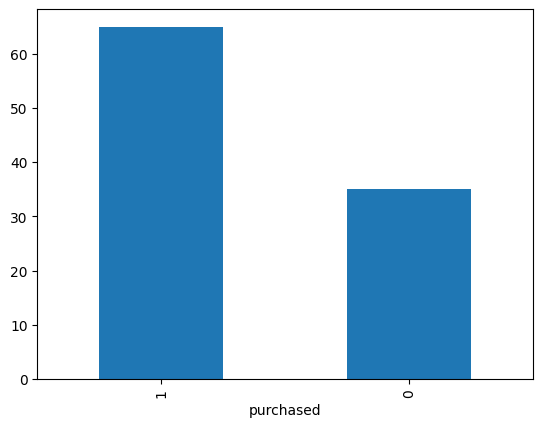

In [ ]:
y_train.value_counts().plot(kind='bar')

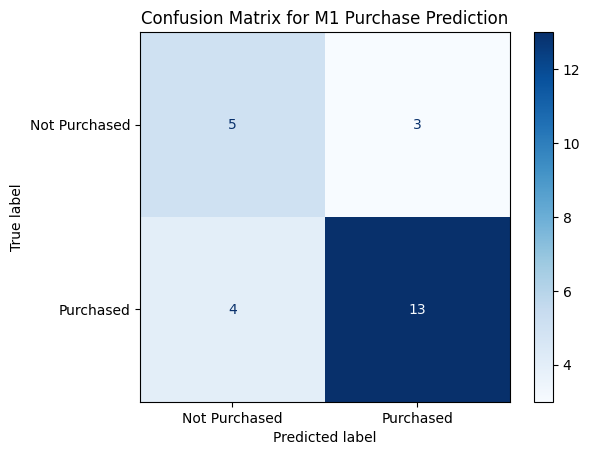

               precision    recall  f1-score   support

Not Purchased       0.56      0.62      0.59         8
    Purchased       0.81      0.76      0.79        17

     accuracy                           0.72        25
    macro avg       0.68      0.69      0.69        25
 weighted avg       0.73      0.72      0.72        25



In [ ]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

**Imbalance Problem.**

In [ ]:
# Threshold Adjusting
from sklearn.metrics import precision_recall_curve, classification_report

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

# Get probabilities instead of hard predictions
y_probs = lr.predict_proba(X_test)[:, 1]

# Find the optimal threshold using Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# We calculate F1-score for each threshold to find the "sweet spot"
f1_scores = (2 * precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

custom_threshold = 0.2
print(f"Optimal Threshold found: {best_threshold:.4f}")

# Apply the custom threshold to get final predictions
y_pred_tuned = (y_probs >= custom_threshold).astype(int)

# Evaluate
print(classification_report(y_test, y_pred_tuned))

Optimal Threshold found: 0.0666
              precision    recall  f1-score   support

           0       0.50      0.38      0.43         8
           1       0.74      0.82      0.78        17

    accuracy                           0.68        25
   macro avg       0.62      0.60      0.60        25
weighted avg       0.66      0.68      0.67        25



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


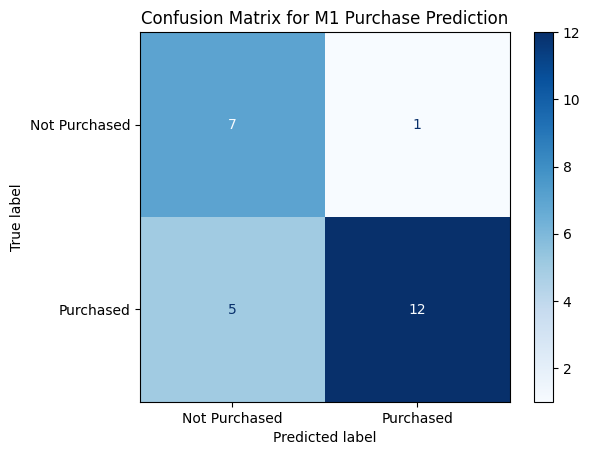

               precision    recall  f1-score   support

Not Purchased       0.58      0.88      0.70         8
    Purchased       0.92      0.71      0.80        17

     accuracy                           0.76        25
    macro avg       0.75      0.79      0.75        25
 weighted avg       0.81      0.76      0.77        25



In [ ]:
# using class weights
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

In [ ]:
# Calculate precision and recall for all possible thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Find the threshold that maximizes the F1-score (harmonic mean of prec/rec)
fscore = (2 * precision * recall) / (precision + recall)
ix = np.argmax(fscore)

print(f'Best Threshold={thresholds[ix]:.2f}, F-Score={fscore[ix]:.2f}')

Best Threshold=0.00, F-Score=0.81


In [ ]:
def log_regression(X_train, X_test, y_train, y_test):
    lr = LogisticRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for M1 Purchase Prediction")
    plt.show()

    print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

**Oversampling**

In [ ]:
# Random oversampling
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

In [ ]:
y_train_res.value_counts()

purchased
0    65
1    65
Name: count, dtype: int64

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


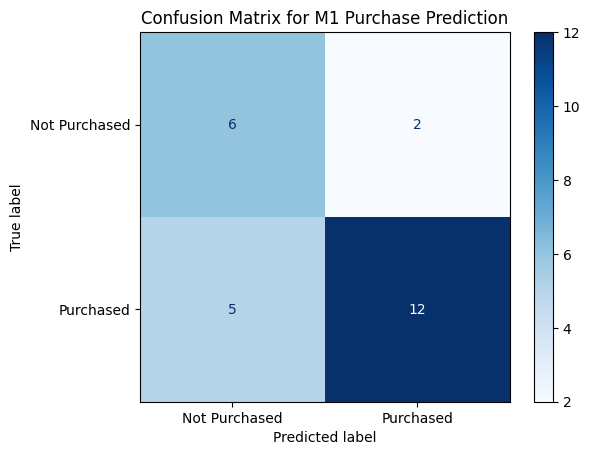

               precision    recall  f1-score   support

Not Purchased       0.55      0.75      0.63         8
    Purchased       0.86      0.71      0.77        17

     accuracy                           0.72        25
    macro avg       0.70      0.73      0.70        25
 weighted avg       0.76      0.72      0.73        25



In [ ]:
log_regression(X_train_res, X_test, y_train_res, y_test)

In [ ]:
# Using SMOTE
from imblearn.over_sampling import SMOTE
sm= SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


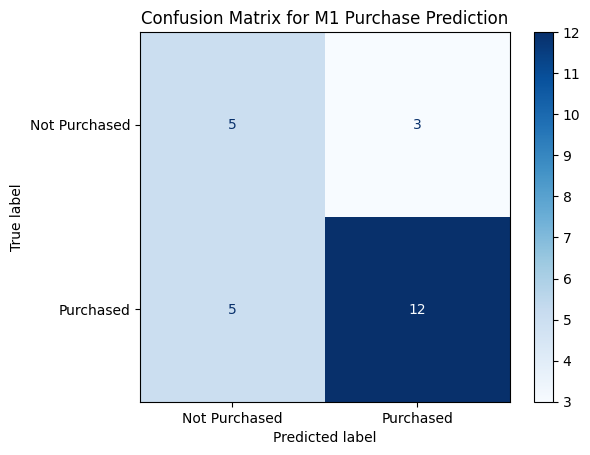

               precision    recall  f1-score   support

Not Purchased       0.50      0.62      0.56         8
    Purchased       0.80      0.71      0.75        17

     accuracy                           0.68        25
    macro avg       0.65      0.67      0.65        25
 weighted avg       0.70      0.68      0.69        25



In [ ]:
log_regression(X_train_res, X_test, y_train_res, y_test)

**Oversampling**

In [ ]:
# Random Undersampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


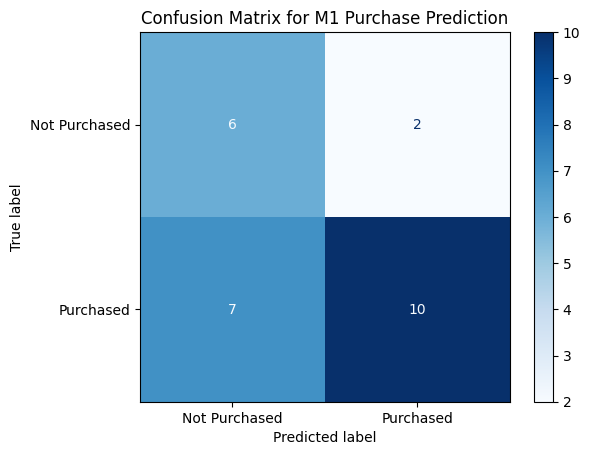

               precision    recall  f1-score   support

Not Purchased       0.46      0.75      0.57         8
    Purchased       0.83      0.59      0.69        17

     accuracy                           0.64        25
    macro avg       0.65      0.67      0.63        25
 weighted avg       0.71      0.64      0.65        25



In [ ]:
log_regression(X_train_res, X_test, y_train_res, y_test)

In [ ]:
# tomek links
from imblearn.under_sampling import TomekLinks

tl= TomekLinks()
X_train_res, y_train_res = tl.fit_resample(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


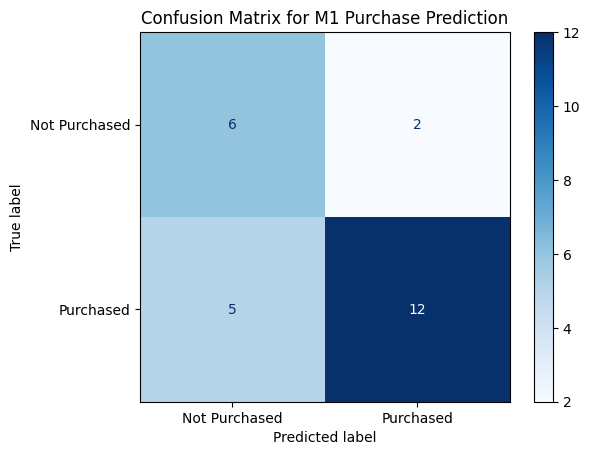

               precision    recall  f1-score   support

Not Purchased       0.55      0.75      0.63         8
    Purchased       0.86      0.71      0.77        17

     accuracy                           0.72        25
    macro avg       0.70      0.73      0.70        25
 weighted avg       0.76      0.72      0.73        25



In [ ]:
log_regression(X_train_res, X_test, y_train_res, y_test)

In [ ]:
# tomek links + SMOTE
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

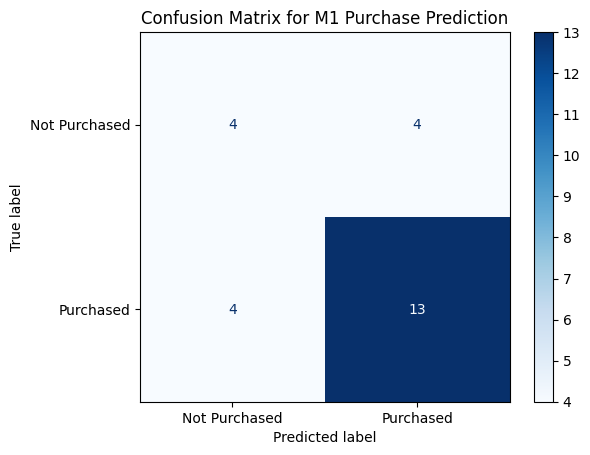

               precision    recall  f1-score   support

Not Purchased       0.50      0.50      0.50         8
    Purchased       0.76      0.76      0.76        17

     accuracy                           0.68        25
    macro avg       0.63      0.63      0.63        25
 weighted avg       0.68      0.68      0.68        25



In [ ]:
log_regression(X_train_res, X_test, y_train_res, y_test)

**Ensemble Methods**

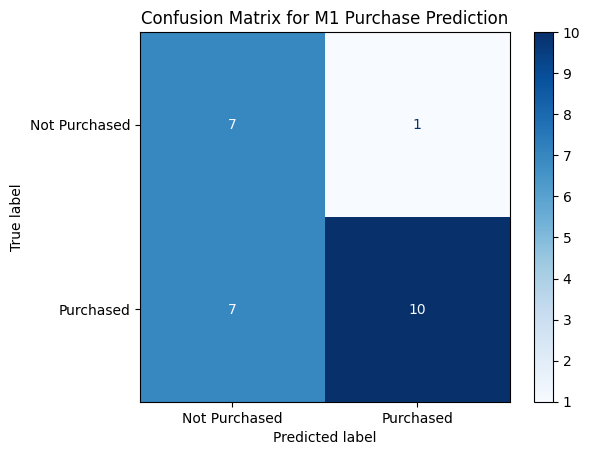

               precision    recall  f1-score   support

Not Purchased       0.50      0.88      0.64         8
    Purchased       0.91      0.59      0.71        17

     accuracy                           0.68        25
    macro avg       0.70      0.73      0.68        25
 weighted avg       0.78      0.68      0.69        25



In [ ]:
# Easy Ensemble
from imblearn.ensemble import EasyEnsembleClassifier

cl = EasyEnsembleClassifier()
cl.fit(X_train, y_train)
y_pred = cl.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

              precision    recall  f1-score   support

           0       0.50      0.88      0.64         8
           1       0.91      0.59      0.71        17

    accuracy                           0.68        25
   macro avg       0.70      0.73      0.68        25
weighted avg       0.78      0.68      0.69        25



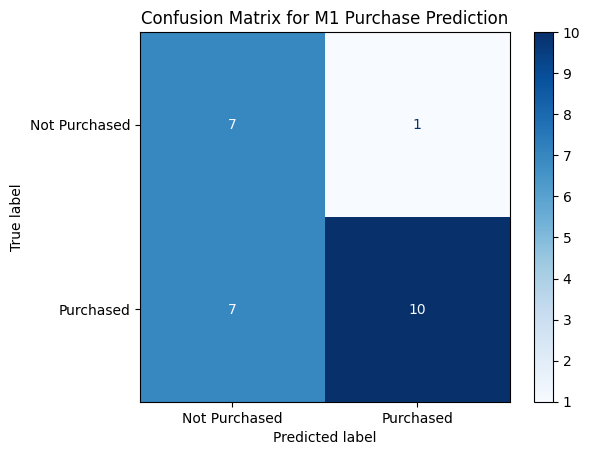

In [ ]:
# Balanced Bagging
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

base_model = DecisionTreeClassifier(max_depth=None)

bbc = BalancedBaggingClassifier(
    estimator=base_model,
    sampling_strategy='auto',
    replacement=False,
    n_estimators=100,
    random_state=42
)

bbc.fit(X_train, y_train)
y_pred = bbc.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()


## Summary of Imbalance Handling Techniques

This notebook explored several techniques to address the class imbalance in the `purchased` target variable. Below is a summary of the F1-scores for the minority class ('Not Purchased') for each method:

*   **Original Logistic Regression:** F1-score (Not Purchased) = 0.59
*   **Threshold Adjusting (custom 0.2):** F1-score (Not Purchased) = 0.43 (Worse)
*   **Logistic Regression with `class_weight='balanced'`:** F1-score (Not Purchased) = **0.70**
*   **Random Oversampling (ROS):** F1-score (Not Purchased) = 0.63
*   **SMOTE:** F1-score (Not Purchased) = 0.56 (Worse)
*   **Random Undersampling (RUS):** F1-score (Not Purchased) = 0.57 (Worse)
*   **TomekLinks Undersampling:** F1-score (Not Purchased) = 0.63
*   **SMOTETomek (SMOTE + TomekLinks):** F1-score (Not Purchased) = 0.50 (Worse)
*   **EasyEnsembleClassifier:** F1-score (Not Purchased) = 0.64
*   **BalancedBaggingClassifier:** F1-score (Not Purchased) = 0.64

### Conclusion

Based on the F1-score for the minority class ('Not Purchased'), the **Logistic Regression with `class_weight='balanced'`** technique yielded the best performance, achieving an F1-score of 0.70. This method successfully improved the model's ability to identify the minority class without significantly sacrificing overall accuracy compared to the original model. While other techniques like EasyEnsemble and BalancedBagging also showed improvements, `class_weight='balanced'` provided the highest F1-score for the class of interest in this analysis.